# Introduction
This web site is running a "Jupyter notebook," which allows you to execute interactive Octave
code directly in your browser. Each (part of a code) line preceeded by a percent symbol "%" is a code comment.

To execute any Octave commands, first enter the commands in a code cell, and then depress the "shift" and "enter" keys on your keyboard at the same time, making sure that your cursor is placed inside of the code cell.
I refer to this as "< shift \> < enter \>" in my instructions below.

The output from this notebook will be used to provide answers for this lesson's practice
quiz. As you proceed through the specialization, you will use more and more Jupyter notebooks
to write Octave code to implement Kalman-filter algorithms.

In [27]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. 
% Data file contains the variables: model dT t u x z
load readonly/simOut.mat
t = t(1:10000); % crop "t" because simulation is slow; this shortens sim time.
x = x(:,1:10000); % crop x as well
q = [model.k, model.b, model.m]';

% We require the Octave control-systems "package" to implement "expm".
pkg load control

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Helper functions for the sigma-point Kalman filter for joint state/parameter estimation
The next notebook cells implement the initialization and iteration functions for the SPKF for joint state/parameter estimation.

In [28]:
% SPKF initialization function, called once at the beginning of the simulation
function spkfData = initSPKFjoint(Xhat0,SigmaX0,SigmaW,SigmaV,priorU)
  spkfData.Xhat   = Xhat0;        % Initial state description  
  spkfData.SigmaX = SigmaX0;      % Initial estimation-error covariance 
  spkfData.SigmaV = SigmaV;       % Sensor-noise covariance 
  spkfData.SigmaW = SigmaW;       % Process-noise covariance
  spkfData.priorU = priorU;       % Previous value of input force
  spkfData.Qbump  = 5;     % In case SigmaX collapses

  spkfData.Snoise = real(chol(blkdiag(SigmaW,SigmaV),'lower'));
  
  % SPKF specific parameters
  nX = length(spkfData.Xhat); spkfData.nX = nX; % "state"-vector length
  nz = 1; spkfData.nz = nz; % measurement-vector length
  nu = 1; spkfData.nu = nu; % input-vector length
  nw = size(SigmaW,1); spkfData.nw = nw; % process-noise-vector length
  nv = size(SigmaV,1); spkfData.nv = nv; % sensor-noise-vector length
  na = nX+nw+nv; spkfData.na = na;     % augmented-state-vector length
  
  h = sqrt(3); 
  spkfData.h = h; % SPKF/CDKF tuning factor  
  Weight1 = (h*h-na)/(h*h); % weighting factors when computing mean
  Weight2 = 1/(2*h*h);      % and covariance
  spkfData.Wm = [Weight1; Weight2*ones(2*na,1)]; % mean
  spkfData.Wc = spkfData.Wm;                     % covar
end

In [29]:
% SPKF iteration function, called once every measurement interval
function [Xhat,bounds,spkfData] = iterSPKFjoint(uk,zk,dT,spkfData)
  SQRT = @(x) sqrt(max(0,x)); % "Safe" square root

  % Get data stored in spkfData structure
  priorU = spkfData.priorU;
  SigmaX = spkfData.SigmaX;
  Xhat = spkfData.Xhat;
  nX = spkfData.nX;
  nw = spkfData.nw;
  nv = spkfData.nv;
  na = spkfData.na;
  Snoise = spkfData.Snoise;
  Wc = spkfData.Wc;
  
  % Step 1a: State estimate time update
  %          - Create xhatminus augmented SigmaX points
  %          - Extract xhatminus state SigmaX points
  %          - Compute weighted average xhatminus(k)

  % Step 1a-1: Create augmented SigmaX and xhat
  [sigmaXa,p] = chol(SigmaX,'lower'); 
  if p>0
    fprintf('Cholesky error.  Recovering...\n');
    theAbsDiag = abs(diag(SigmaX));
    sigmaXa = diag(max(SQRT(theAbsDiag),SQRT(diag(spkfData.SigmaW))));
  end
  sigmaXa=[real(sigmaXa) zeros([nX nw+nv]); zeros([nw+nv nX]) Snoise];
  xhata = [Xhat; zeros([nw+nv 1])];
  % NOTE: sigmaXa is lower-triangular

  % Step 1a-2: Calculate SigmaX points (strange indexing of xhata to 
  % avoid "repmat" call, which is very inefficient in MATLAB)
  Xa = xhata(:,ones([1 2*na+1])) + ...
       spkfData.h*[zeros([na 1]), sigmaXa, -sigmaXa];

  % Step 1a-3: Time update from last iteration until now
  %     stateEqn(xold,current,xnoise)
  Xx = stateEqn(Xa(1:nX,:),priorU,dT,Xa(nX+1:nX+nw,:)); 
  Xhat = Xx*spkfData.Wm;

  % Step 1b: Error covariance time update
  %          - Compute weighted covariance sigmaminus(k)
  %            (strange indexing of xhat to avoid "repmat" call)
  Xs = Xx - Xhat(:,ones([1 2*na+1]));
  SigmaX = Xs*diag(Wc)*Xs';
  
  % Step 1c: Output estimate
  %          - Compute weighted output estimate yhat(k)
  Z = outputEqn(Xx,Xa(nX+nw+1:end,:));
  zhat = Z*spkfData.Wm;

  % Step 2a: Estimator gain matrix
  Zs = Z - zhat(:,ones([1 2*na+1]));
  SigmaXZ = Xs*diag(Wc)*Zs';
  SigmaZ  = Zs*diag(Wc)*Zs';
  L = SigmaXZ/SigmaZ; 

  % Step 2b: State estimate measurement update
  r = zk - zhat; % residual.  Use to check for sensor errors...
  if r^2 > 100*SigmaZ, L(:)=0.0; end 
  Xhat = Xhat + L*r;

  % Step 2c: Error covariance measurement update
  SigmaX = SigmaX - L*SigmaZ*L';

  % Q-bump code
  % if r^2 > 6.25*SigmaZ % bad output estimate by 2.5 std. devs, bump Q 
  %   fprintf('Bumping SigmaX\n');
  %   SigmaX = SigmaX*spkfData.Qbump;
  % end
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  spkfData.priorU = uk;
  spkfData.SigmaX = SigmaX;
  spkfData.Xhat = Xhat;
  bounds = 3*sqrt(diag(SigmaX));
  
  % Calculate new states for all of the old state vectors in xold.  
  function Xnew = stateEqn(Xold,priorU,dT,xnoise)
    Xnew = 0*Xold;
    for kk = 1:size(Xold,2)
      priorX = Xold(1:2,kk); qhat = Xold(3:5,kk);
      k = qhat(1); b = qhat(2); m = qhat(3); 
      A = [0 1; -k/m -b/m]; % Specify continuous-time model
      B = [0; 1/m]; 
      Ad = expm(A*dT); Bd = (A\(Ad-eye(2)))*B;
      
      Xnew(:,kk) = [Ad*priorX + Bd*priorU; qhat]; % [xk;theta] pred
    end
    Xnew = Xnew + xnoise;
  end

  % Calculate output for all of state vectors in xhat
  function zhat = outputEqn(xhat,znoise)
    zhat = xhat(1,:) + znoise;
  end
end

### Implementing the sigma-point Kalman filter for joint state/parameter estimation
The next notebook cells implement the main code of the sigma-point Kalman filter.

In [30]:
% Determine number of states and timesteps
[nx,~] = size(x); nt = length(t);

% Reserve storage for computed results, for plotting
nq         = length(q);
XhatSPKFstore  = zeros(nx+nq,nt);
boundSPKFstore = zeros(nx+nq,nt);

% Covariance values
q0      = [2;1;40];
SigmaQ0 = diag((q-q0)/2)^2; % uncertainty of initial parameters
SigmaQW  = diag(1e-16*[1 1 1]);

% Covariance values
xhat0   = zeros(nx,1);
SigmaX0 = 0.1*eye(nx); % uncertainty of initial state

% Create spkfData structure and initialize variables 
spkfData = initSPKFjoint([xhat0;q0],blkdiag(SigmaX0,SigmaQ0),...
  blkdiag(model.SigmaW,SigmaQW),model.SigmaV,u(1));

% Now, enter loop for remainder of time, where we update the SPKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input force
  zk = z(k); % "measure" nonlinear output
  
  % Update SOC (and other model states)
  [XhatSPKFstore(:,k),boundSPKFstore(:,k),spkfData] = iterSPKFjoint(uk,zk,dT,spkfData);
  if mod(k,2000)==0
    fprintf('Completed %d out of %d iterations\n',k,nt);
  end 
end
spkfErr = [x; repmat(q,1,nt)] - XhatSPKFstore;
spkfBnd = boundSPKFstore;

Completed 2000 out of 10000 iterations
Completed 4000 out of 10000 iterations
Completed 6000 out of 10000 iterations
Completed 8000 out of 10000 iterations
Completed 10000 out of 10000 iterations


### Plot simulation outputs from the sigma-point Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

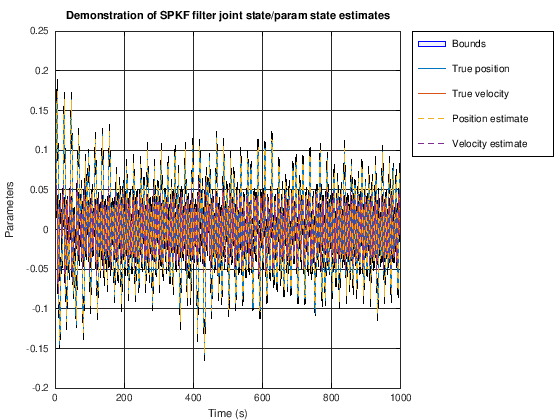

In [31]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [XhatSPKFstore-boundSPKFstore fliplr(XhatSPKFstore+boundSPKFstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot(t,x(1:2,:)',t,XhatSPKFstore(1:2,:)','--'); ylim([-0.2 0.25])
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'},"Location","bestoutside"); 
title('Demonstration of SPKF filter joint state/param state estimates'); 
xlabel('Time (s)'); ylabel('Parameters'); 

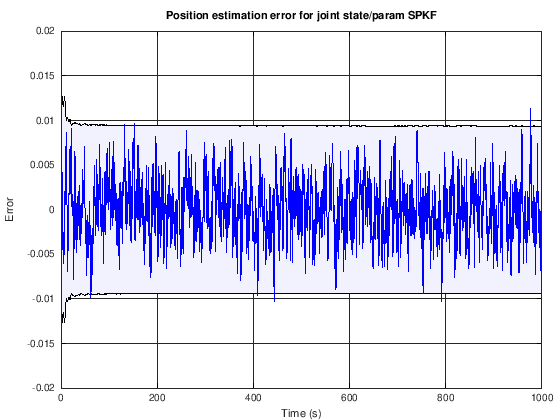

In [32]:
fill([t fliplr(t)],[-boundSPKFstore(1,:) fliplr(boundSPKFstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(1,:),'b'); ylim([-0.02 0.02])
title('Position estimation error for joint state/param SPKF'); 
xlabel('Time (s)'); ylabel('Error'); 

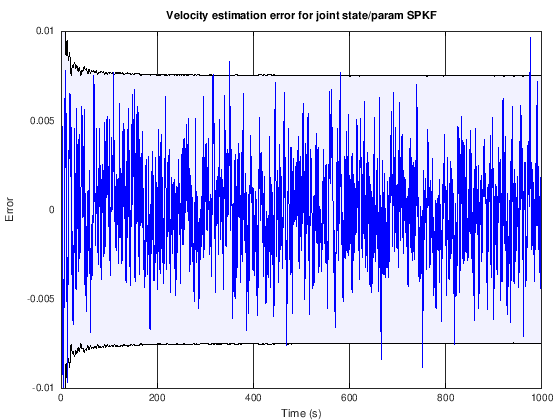

In [33]:
fill([t fliplr(t)],[-boundSPKFstore(2,:) fliplr(boundSPKFstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(2,:),'b'); ylim([-0.01 0.01])
title('Velocity estimation error for joint state/param SPKF'); 
xlabel('Time (s)'); ylabel('Error'); 

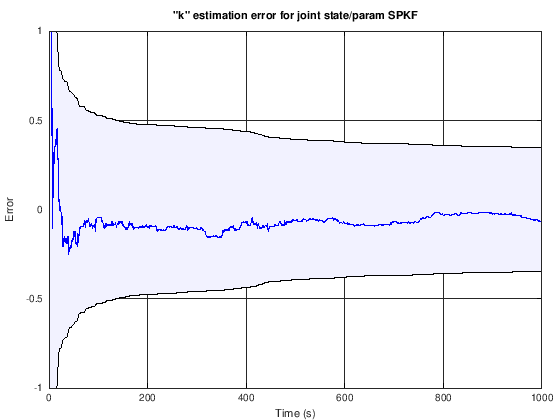

In [34]:
fill([t fliplr(t)],[-boundSPKFstore(3,:) fliplr(boundSPKFstore(3,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(3,:),'b'); ylim([-1 1])
title('"k" estimation error for joint state/param SPKF'); 
xlabel('Time (s)'); ylabel('Error'); 

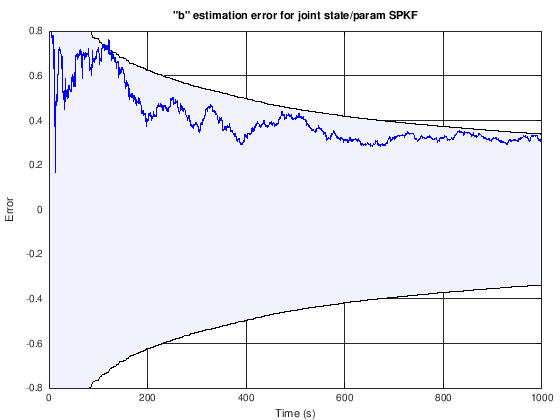

In [35]:
fill([t fliplr(t)],[-boundSPKFstore(4,:) fliplr(boundSPKFstore(4,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(4,:),'b'); ylim([-0.8 0.8])
title('"b" estimation error for joint state/param SPKF'); 
xlabel('Time (s)'); ylabel('Error'); 

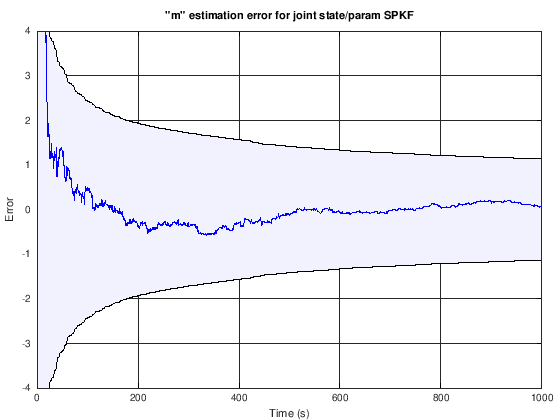

In [36]:
fill([t fliplr(t)],[-boundSPKFstore(5,:) fliplr(boundSPKFstore(5,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,spkfErr(5,:),'b'); ylim([-4 4])
title('"m" estimation error for joint state/param SPKF'); 
xlabel('Time (s)'); ylabel('Error'); 

In [39]:
% Compute and output some statistics
fprintf('RMS parameter estimation error = %g\n',rms(spkfErr(:)));
ind = find(abs(spkfErr(:))>boundSPKFstore(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundSPKFstore(:))*100);

RMS parameter estimation error = 0.542213
Time error outside bounds = 0.182%


In [41]:
rms(boundSPKFstore(:))

ans =  0.99113


### Helper functions for the extended Kalman filter for joint state/parameter estimation
The next notebook cells implement the initialization and iteration functions for the EKF for joint state/parameter estimation.

In [13]:
% EKF initialization function, called once at the beginning of the simulation
function ekfData = initEKFjoint(Xhat0,SigmaX0,SigmaW,SigmaV,priorU,dT)
  ekfData.Xhat   = Xhat0;        % Initial state description  
  ekfData.SigmaX = SigmaX0;      % Initial estimation-error covariance 
  ekfData.SigmaV = SigmaV; % Sensor-noise covariance 
  ekfData.SigmaW = SigmaW; % Process-noise covariance
  ekfData.priorU = priorU;       % Previous value of input force
  ekfData.Qbump  = 5;     % In case SigmaX collapses

  % In MATLAB, we can compute the required derivatives symbolically. Perhaps we can 
  % do this in Octave also, but I don't know how. In MATLAB, we can write:
  % % Compute the derivative of the output with respect to the parameters
  % syms k b m x1old x2old uold 
  % sA = [0 1; -k/m -b/m];
  % sB = [0; 1/m];
  % sAd = expm(sA*dT);
  % sBd = (sA\(sAd-eye(2)))*sB;
  % sxold = [x1old; x2old];  
  % sAhat = simplify(jacobian(sAd*sxold + sBd*uold,[x1old x2old k b m]));  

  % ekfData.Ad = matlabFunction(sAd); % Ad as a function of parameters
  % ekfData.Bd = matlabFunction(sBd); % Bd as a function of parameters
  % ekfData.Ahat = matlabFunction(sAhat); % Ahat as a function of stuff
end

In [14]:
% This is the Ad function that we need for the state-prediction time update. The terms
% were computed originally by MATLAB; I copied and pasted them here. As you might imagine,
% this would have been nearly impossible to compute by hand (correctly).
function Ad = ekfAd(b,k,m)
  Ad = zeros(2,2);
  Ad(1,1) = (exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - b*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(2*(b^2 - 4*k*m)^(1/2));
  Ad(2,1) = -(k*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - k*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(b^2 - 4*k*m)^(1/2);
  Ad(1,2) = (m*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - m*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(b^2 - 4*k*m)^(1/2);
  Ad(2,2) = (exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - b*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(2*(b^2 - 4*k*m)^(1/2));
end

In [15]:
% This is the Bd function that we need for the state-prediction time update. The terms
% were computed originally by MATLAB; I copied and pasted them here. As you might imagine,
% this would have been nearly impossible to compute by hand (correctly).
function Bd = ekfBd(b,k,m)
  Bd = zeros(2,1);
  Bd(1,1) = -(exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*(b^2 - 4*k*m)^(1/2) - b*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(2*k*(b^2 - 4*k*m)^(1/2));
  Bd(2,1) = -(exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)))/(b^2 - 4*k*m)^(1/2);
end

In [16]:
% This is the Jacobian function that we need when computing Ahat. The terms of the Jacobian
% were computed originally by MATLAB; I copied and pasted them here. As you might imagine,
% this would have been nearly impossible to compute by hand (correctly).
function Ahat = ekfAhat(b,k,m,uold,x1old,x2old)
  Ahat = zeros(2,5);
  Ahat(1,1) = (exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - b*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(2*(b^2 - 4*k*m)^(1/2));
  Ahat(2,1) = -(k*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - k*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(b^2 - 4*k*m)^(1/2);
  Ahat(1,2) = (m*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - m*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(b^2 - 4*k*m)^(1/2);
  Ahat(2,2) = (exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - b*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)))/(2*(b^2 - 4*k*m)^(1/2));
  Ahat(1,3) = -(20*uold*(b^2 - 4*k*m)^(3/2) - 10*b^3*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 10*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 10*b^3*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 10*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + b^2*k*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 4*k^2*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 4*k^3*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - b^2*k*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - b^2*k^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 4*k^2*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 4*k^3*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 40*k^2*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*k^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*k^2*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 60*b*k*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b*k^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k^2*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - b*k*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 60*b*k*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 20*b*k^2*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - b*k*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*k^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k^2*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 20*b*k^2*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)))/(20*k^2*(b^2 - 4*k*m)^(3/2));
  Ahat(2,3) = (10*b^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 10*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 10*b^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 40*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 10*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 2*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 20*b*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + b*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 20*b*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(20*(b^2 - 4*k*m)^(3/2));
  Ahat(1,4) = (uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - 80*k*m^2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - b^2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 80*k*m^2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 80*k^2*m^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 8*k^2*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - b^2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 80*k^2*m^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 8*k^2*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 40*b*k*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b^2*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 40*b*k*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*b^2*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*b*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(40*k*m*(b^2 - 4*k*m)^(3/2));
  Ahat(2,4) = -(2*b^2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*b^3*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - 2*b^2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b^3*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 40*b*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b^2*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 8*k*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 8*k^2*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 80*k*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*b*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*b^2*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 8*k^2*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 80*k*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*b*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 8*k*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*b*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 40*b*k*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 8*b*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 40*b*k*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 8*b*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*b*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(40*m*(b^2 - 4*k*m)^(3/2));
  Ahat(1,5) = -(2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 10*b^3*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 10*b^3*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - 2*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 20*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 40*b*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 20*b^2*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*b*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 10*b*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 2*b*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + b^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 20*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 20*b^2*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*b*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*b*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 10*b*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) - 2*b*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(- b^2 + 4*k*m) + 2*b*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*b*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(40*m*(b^2 - 4*k*m)^(3/2));
  Ahat(2,5) = (b^3*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - b^4*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - b^3*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b^4*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + b^3*k*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*k*m^2*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + b*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) - b^3*k*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 40*k*m^2*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 40*k^2*m^2*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 4*k^2*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 40*k^2*m^2*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 4*k^2*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + b*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(3/2) + 4*b*k*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 2*k^2*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 2*k*m*uold*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) - 4*b*k*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 4*b*k^2*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) + 20*b*k*m^2*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 5*b^2*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m)) - 2*k*m*uold*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 2*k^2*m*x1old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + 4*b*k^2*m*x1old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) - 20*b*k*m^2*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + 5*b^2*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m)) + b*k*m*x2old*exp(-(b - (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2) + b*k*m*x2old*exp(-(b + (b^2 - 4*k*m)^(1/2))/(20*m))*(b^2 - 4*k*m)^(1/2))/(20*m^2*(b^2 - 4*k*m)^(3/2));  
end 

In [17]:
% EKF iteration function, called once every measurement interval
function [Xhat,bounds,ekfData] = iterEKFjoint(uk,zk,dT,ekfData)
  
  % Get data stored in ekfData structure
  priorU = ekfData.priorU;
  SigmaX = ekfData.SigmaX;
  SigmaV = ekfData.SigmaV;
  SigmaW = ekfData.SigmaW;
  Xhat = ekfData.Xhat;
  
  % EKF Step 0: Extract components of joint state vector (xhatplus_k-1)
  %             and compute Ad, Bd, and Ahat
  x1 = Xhat(1); x2 = Xhat(2); k = Xhat(3); b = Xhat(4);  m = Xhat(5);
  %Ad = real(ekfData.Ad(b,k,m));
  %Bd = real(ekfData.Bd(b,k,m));
  %Ahat = ekfData.Ahat(b,k,m,priorU,x1,x2);
  Ad = real(ekfAd(b,k,m));
  Bd = real(ekfBd(b,k,m));
  Ahat = ekfAhat(b,k,m,priorU,x1,x2);
  Ahat = [real(Ahat); zeros(3,2), eye(3)];
  
  % Step 1a: State prediction time update
  Xhat(1:2) = Ad*Xhat(1:2) + Bd*priorU;
  % "Q" states don't get updated
  
  % Step 1b: Error covariance time update
  %          sigmaminus(k) = Ahat(k-1)*sigmaplus(k-1)*Ahat(k-1)' + ...
  %                          Bhat(k-1)*sigmawtilde*Bhat(k-1)'
  SigmaX = Ahat*SigmaX*Ahat' + SigmaW';
  
  % Step 1c: Output prediction
  zhat = Xhat(1);
  
  % Step 2a: Estimator gain matrix
  Chat = [1 0 0 0 0]; 
  SigmaZ = Chat*SigmaX*Chat' + SigmaV;
  L = SigmaX*Chat'/SigmaZ;
  
  % Step 2b: State estimate measurement update
  r = zk - zhat; % residual.  Use to check for sensor errors...
  if r^2 > 100*SigmaZ, L(:)=0.0; end 
  Xhat = Xhat + L*r;
  
  % Step 2c: Error covariance measurement update
  SigmaX = SigmaX - L*SigmaZ*L';

  % Q-bump code
  % if r^2 > 6.25*SigmaZ % bad output estimate by 2.5 std. devs, bump Q 
  %   fprintf('Bumping SigmaX\n');
  %   SigmaX = SigmaX*ekfData.Qbump;
  % end
  [~,S,V] = svd(SigmaX); % Implement Higham method to help robustness
  HH = V*S*V';
  SigmaX = (SigmaX + SigmaX' + HH + HH')/4; 
  
  % Save data in ekfData structure for next time...
  ekfData.priorU = uk;
  ekfData.SigmaX = SigmaX;
  ekfData.Xhat = Xhat;
  bounds = 3*sqrt(diag(SigmaX));
end

### Implementing the extended Kalman filter for joint state/parameter estimation
The next notebook cells implement the main code of the extended Kalman filter.

In [18]:
% Determine number of states and timesteps
[nx,~] = size(x); nt = length(t);

% Reserve storage for computed results, for plotting
nq         = length(q);
XhatEKFstore  = zeros(nx+nq,nt);
boundEKFstore = zeros(nx+nq,nt);

% Covariance values
q0      = [2;1;40];
SigmaQ0 = diag((q-q0)/2)^2; % uncertainty of initial parameters
SigmaQW  = diag(1e-16*[1 1 1]);

% Covariance values
xhat0   = zeros(nx,1);
SigmaX0 = 0.1*eye(nx); % uncertainty of initial state

% Create spkfData structure and initialize variables 
ekfData = initEKFjoint([xhat0;q0],blkdiag(SigmaX0,SigmaQ0),...
  blkdiag(model.SigmaW,SigmaQW),model.SigmaV,u(1));

% Now, enter loop for remainder of time, where we update the SPKF
% once per sample interval
for k = 2:length(t)
  uk = u(k); % "measure" input force
  zk = z(k); % "measure" nonlinear output
  
  % Update SOC (and other model states)
  [XhatEKFstore(:,k),boundEKFstore(:,k),ekfData] = iterEKFjoint(uk,zk,dT,ekfData);
  if mod(k,2000)==0
    fprintf('Completed %d out of %d iterations\n',k,nt);
  end 
end
ekfErr = [x; repmat(q,1,nt)] - XhatEKFstore;
ekfBnd = boundEKFstore;

Completed 2000 out of 10000 iterations
Completed 4000 out of 10000 iterations
Completed 6000 out of 10000 iterations
Completed 8000 out of 10000 iterations
Completed 10000 out of 10000 iterations


### Plot simulation outputs from the extended Kalman filter
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

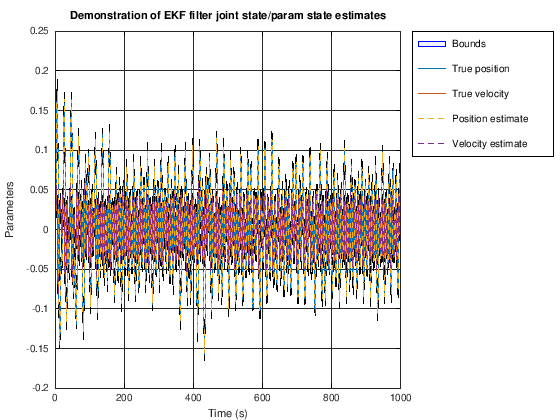

In [19]:
% Plot the states with confidence bounds
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [XhatEKFstore-boundEKFstore fliplr(XhatEKFstore+boundEKFstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
fill(t2,x2(2,:),'b',"FaceAlpha",0.05); 

h2 = plot(t,x(1:2,:)',t,XhatEKFstore(1:2,:)','--'); ylim([-0.2 0.25])
legend([h2;h1a],{'True position','True velocity','Position estimate',...
  'Velocity estimate','Bounds'},"Location","bestoutside"); 
title('Demonstration of EKF filter joint state/param state estimates'); 
xlabel('Time (s)'); ylabel('Parameters'); 

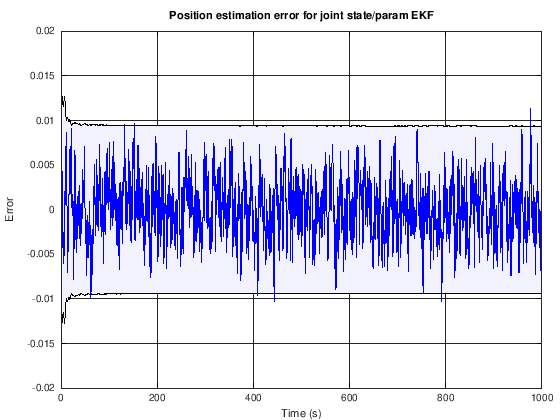

In [20]:
fill([t fliplr(t)],[-boundEKFstore(1,:) fliplr(boundEKFstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(1,:),'b'); ylim([-0.02 0.02])
title('Position estimation error for joint state/param EKF'); 
xlabel('Time (s)'); ylabel('Error'); 

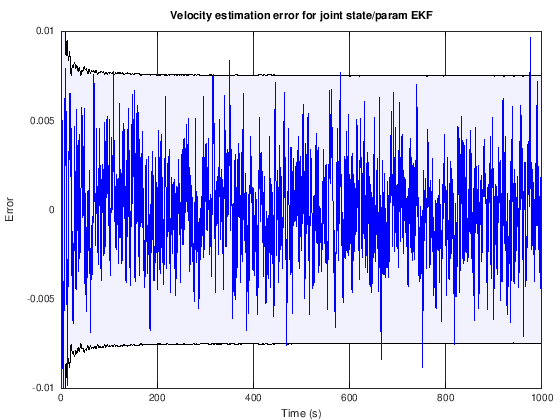

In [21]:
fill([t fliplr(t)],[-boundEKFstore(2,:) fliplr(boundEKFstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(2,:),'b'); ylim([-0.01 0.01])
title('Velocity estimation error for joint state/param EKF'); 
xlabel('Time (s)'); ylabel('Error'); 

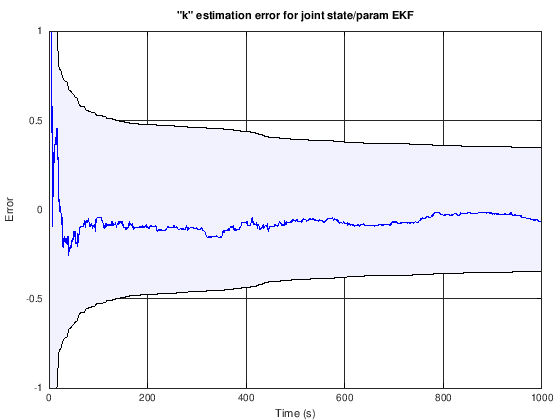

In [22]:
fill([t fliplr(t)],[-boundEKFstore(3,:) fliplr(boundEKFstore(3,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(3,:),'b'); ylim([-1 1])
title('"k" estimation error for joint state/param EKF'); 
xlabel('Time (s)'); ylabel('Error'); 

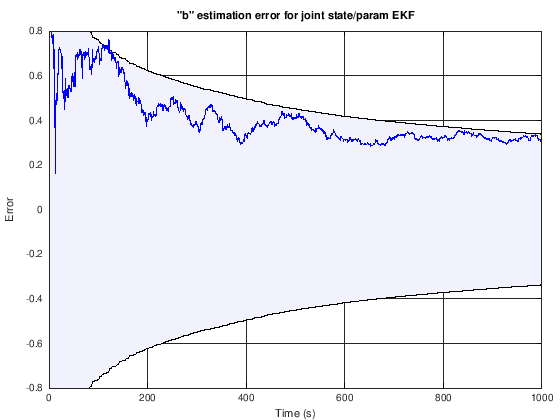

In [23]:
fill([t fliplr(t)],[-boundEKFstore(4,:) fliplr(boundEKFstore(4,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(4,:),'b'); ylim([-0.8 0.8])
title('"b" estimation error for joint state/param EKF'); 
xlabel('Time (s)'); ylabel('Error'); 

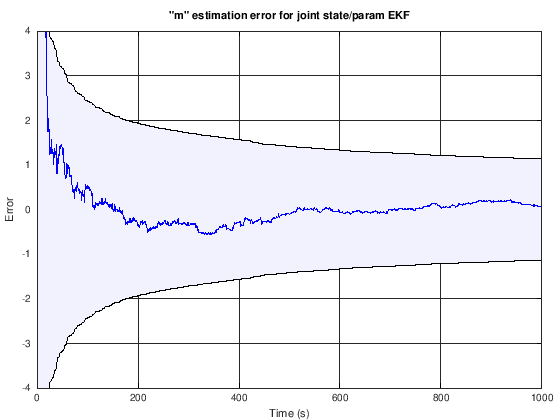

In [24]:
fill([t fliplr(t)],[-boundEKFstore(5,:) fliplr(boundEKFstore(5,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,ekfErr(5,:),'b'); ylim([-4 4])
title('"m" estimation error for joint state/param EKF'); 
xlabel('Time (s)'); ylabel('Error'); 

In [25]:
% Compute and output some statistics
fprintf('RMS parameter estimation error = %g\n',rms(ekfErr(:)));
ind = find(abs(ekfErr(:))>boundEKFstore(:));
fprintf('Time error outside bounds = %g%%\n',length(ind)/length(boundEKFstore(:))*100);

RMS parameter estimation error = 0.551003
Time error outside bounds = 0.218%


In [26]:
rms(boundEKFstore(:))

ans =  0.99301
